In [1]:
# Import numpy
import numpy as np

# Import pandas for data handling
import pandas as pd

import os

# Import plotting libraries
import matplotlib
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8') # pretty matplotlib plots

import seaborn as sns
sns.set('notebook', font_scale=1.25, style='whitegrid')

In [2]:
DATA_PATH = '.'
visualization_file_name = 'trial_results.csv'

In [3]:
if not os.path.exists(os.path.join(DATA_PATH, visualization_file_name)):
    try:
        DATA_PATH = os.path.join(os.environ.get("HOME", ""),
                    '/Users/juliasantaniello/Desktop/OfflineNeuroloop/src/results/')
        assert os.path.exists(os.path.join(DATA_PATH, visualization_file_name))
    except AssertionError:
        print("Please store path to results csv in DATA_PATH")

assert os.path.exists(os.path.join(DATA_PATH, visualization_file_name))

In [4]:
# Try to robustly read the CSV, attempt to handle extra columns due to trailing commas or malformed rows

PATH = os.path.join(DATA_PATH, visualization_file_name)

# Attempt 1: try regular read_csv, fallback to python engine if error, also skip bad lines if needed
try:
    df = pd.read_csv(PATH)
except pd.errors.ParserError:
    try:
        df = pd.read_csv(PATH, engine='python')
    except Exception:
        df = pd.read_csv(PATH, engine='python', on_bad_lines='skip')


In [5]:
results = df 

In [6]:
# Usage
param_cols = [
    'parameters_mlp_model_noise',
    'parameters_neural_temporal_shift',
    # add more here...
]

title_labels = [
    'Model Noise',
    'Temporal Shift',
]

In [7]:
def prepare_exploded(results, metric_col):
    """
    Parse and explode a list-valued metric column into one row per episode.
    
    Args:
        results:    Raw results DataFrame.
        metric_col: 'reward_list' or 'success_list'
    
    Returns:
        Exploded DataFrame with episode column.
    """
    source_col_map = {
        'reward_list': 'results_total_reward',
        'success_list': 'results_success_rate',  # update to match your actual column name
    }
    source_col = source_col_map[metric_col]

    def parse_list(x):
        return eval(x) if isinstance(x, str) else list(x)

    df = results.copy()
    df[metric_col] = df[source_col].apply(parse_list)
    exploded = df.explode(metric_col).copy()
    exploded[metric_col] = exploded[metric_col].astype(float)
    exploded['episode'] = exploded.groupby(level=0)[metric_col].cumcount()
    return exploded

In [8]:
def plot_training_curves(grouped_df, param_col, metric_col, title_label=None):
    """
    Plot training curves grouped by domain, condition, and a specified parameter.
    
    Args:
        grouped_df:  DataFrame with columns: parameters_experiment_domain, 
                     parameters_experiment_condition, the param_col, 'episode', 'mean', 'std'
        param_col:   Column name to group/color lines by (e.g. 'parameters_neural_model_noise')
        metric_col:  Column that was aggregated: 'reward_list' or 'success_list'
        title_label: Human-readable label for the legend title. Defaults to param_col.
    """
    if title_label is None:
        title_label = param_col

    metric_label = 'Total Reward' if metric_col == 'reward_list' else 'Success Rate'

    combos = grouped_df[['parameters_experiment_domain', 'parameters_experiment_condition']].drop_duplicates()

    for idx, (_, row) in enumerate(combos.iterrows()):
        domain = row['parameters_experiment_domain']
        condition = row['parameters_experiment_condition']
        subset = grouped_df[
            (grouped_df['parameters_experiment_domain'] == domain) &
            (grouped_df['parameters_experiment_condition'] == condition)
        ]

        fig, ax = plt.subplots(1, 1, figsize=(7, 5))

        for val in sorted(subset[param_col].unique()):
            val_data = subset[subset[param_col] == val].sort_values('episode')
            episodes = val_data['episode']
            mean = val_data['mean']
            std = val_data['std']
            line, = ax.plot(
                episodes, mean,
                marker='o', markevery=max(1, len(episodes) // 10),
                label=f'{title_label} = {val}'
            )
            ax.fill_between(episodes, mean - std, mean + std, alpha=0.2, color=line.get_color())

        ax.set_title(f'{domain} - {condition}')
        ax.set_xlabel('Episode')
        ax.set_ylabel(metric_label)
        ax.legend(title=title_label, fontsize=8)

        fig.suptitle(f'{metric_label}: {domain} - {condition}', y=1.02)
        plt.tight_layout()
        plt.show()

In [9]:
def plot_all_params(exploded, param_cols, metric_col='reward_list', title_labels=None):
    """
    Run plot_training_curves for each parameter in param_cols.
    
    Args:
        exploded:     Raw exploded DataFrame before groupby.
        param_cols:   List of column names to iterate over.
        metric_col:   Column to use as the y-axis: 'reward_list' or 'success_list'.
        title_labels: Optional list of human-readable labels (same length as param_cols).
    """
    if title_labels is None:
        title_labels = [None] * len(param_cols)

    for param_col, title_label in zip(param_cols, title_labels):
        grouped = (
            exploded
            .groupby(['parameters_experiment_domain', 'parameters_experiment_condition', param_col, 'episode'])[metric_col]
            .agg(['mean', 'std'])
            .reset_index()
        )
        plot_training_curves(grouped, param_col, metric_col, title_label)



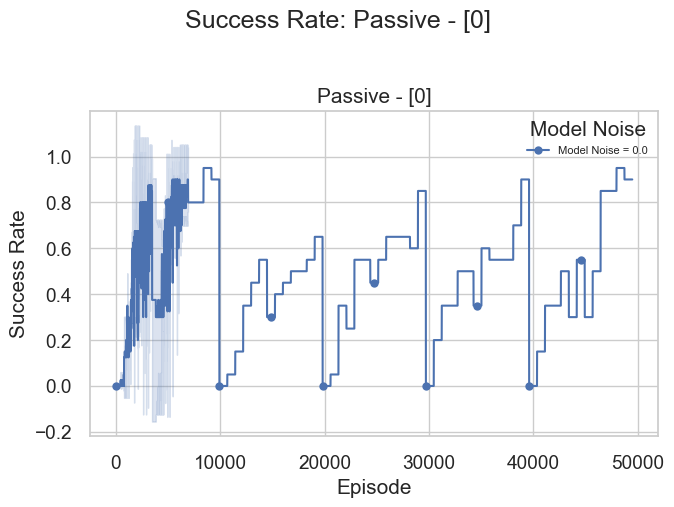

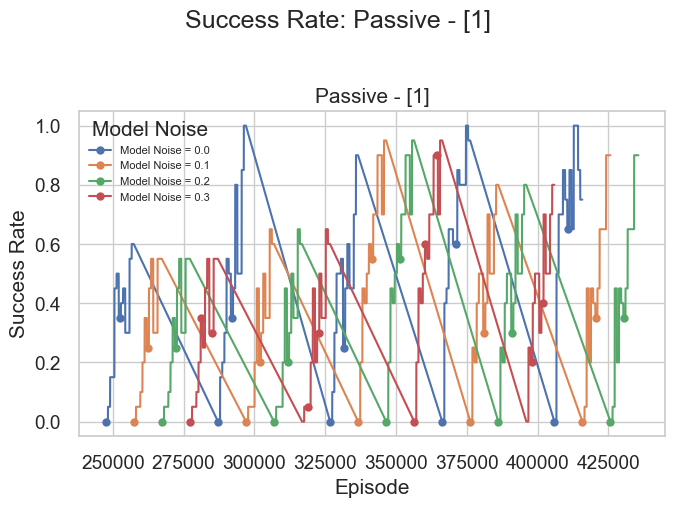

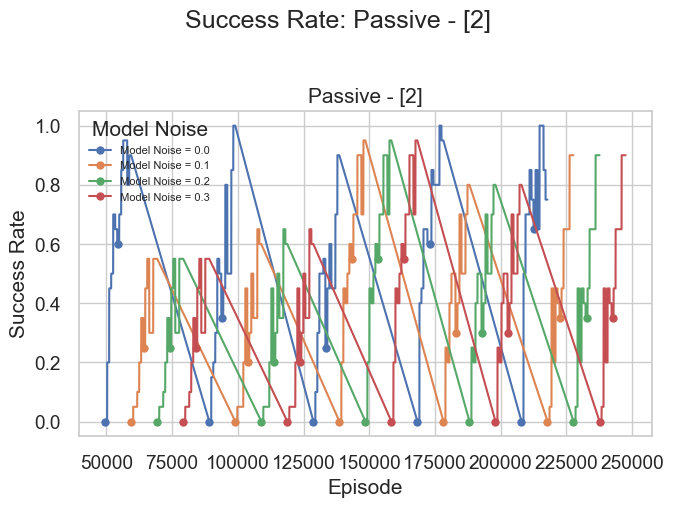

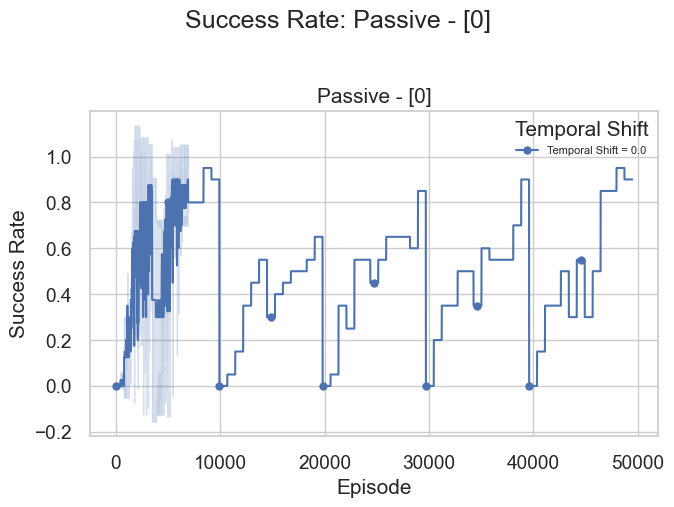

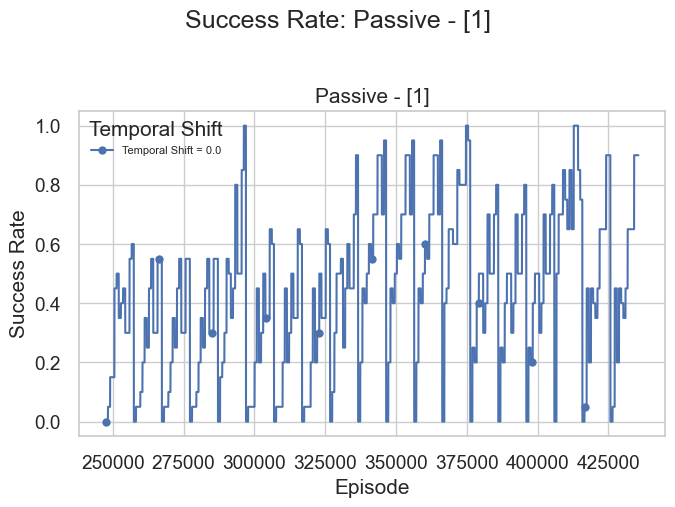

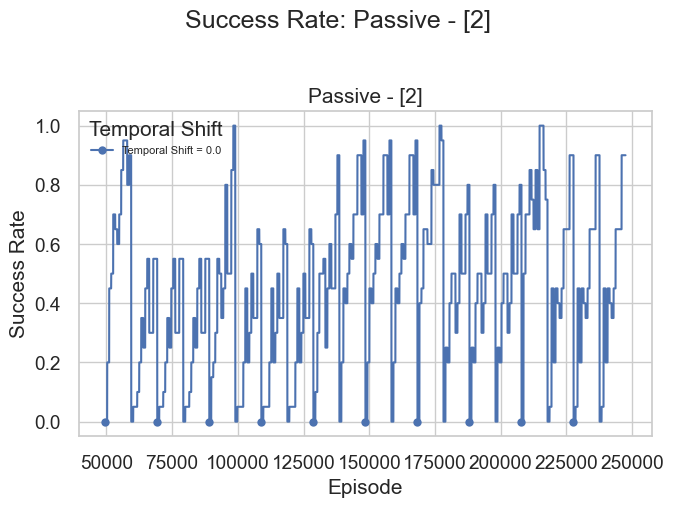

In [10]:
plot_all_params(
    prepare_exploded(results, 'success_list'),
    param_cols,
    metric_col='success_list',
    title_labels=title_labels,
)

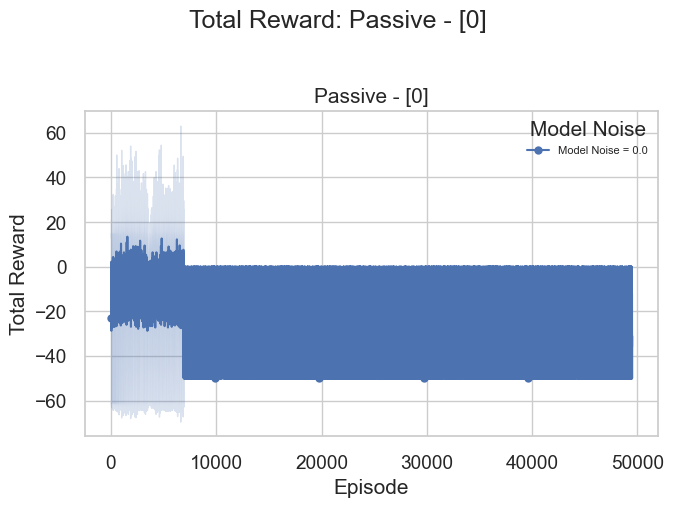

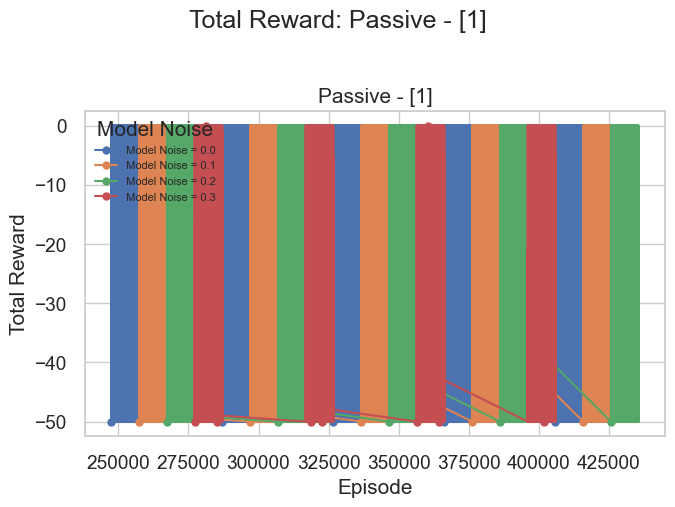

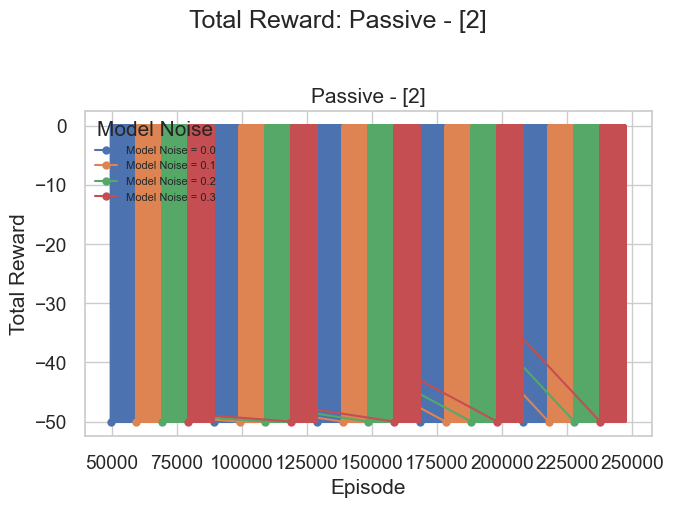

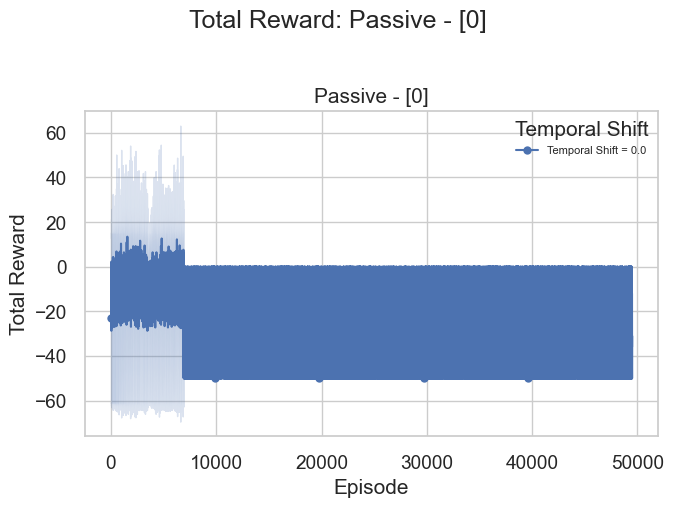

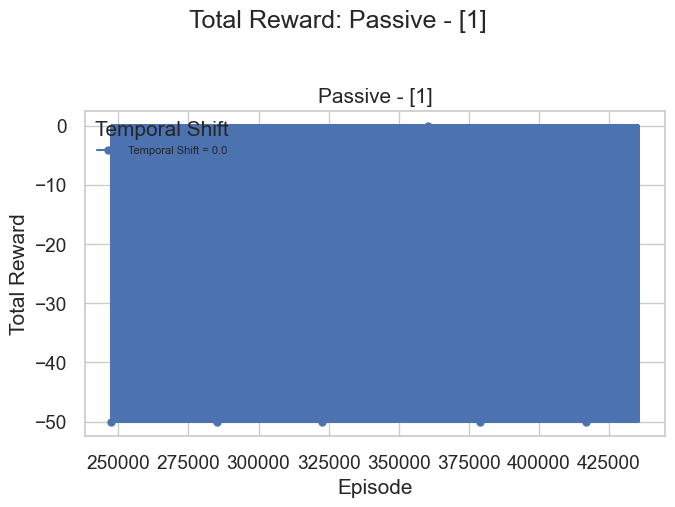

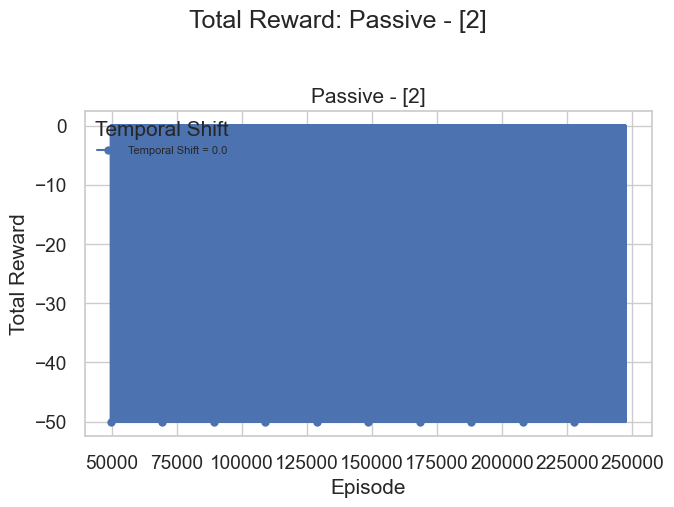

In [11]:
plot_all_params(
    prepare_exploded(results, 'reward_list'),
    param_cols,
    metric_col='reward_list',
    title_labels=title_labels,
)